# Adaptive Exploration: UCB Algorithm

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the Upper Confidence Bound (UCB) rule and where its bonus term comes from
- Implement UCB for a multi-armed bandit
- Compare UCB with ε-greedy and Thompson sampling on the same problem
- Apply adaptive exploration to a simple MDP (FrozenLake)

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 5, lesson 08 "Computing P-values and Confidence Intervals" — UCB's bonus term *is* a confidence bound: the fewer times an action has been tried, the wider its interval, and the algorithm simply acts on the optimistic end of it.

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 4**.

---


## Lesson Brief

This lesson introduces **Upper Confidence Bound (UCB)** style exploration.

Students will see how uncertainty itself can be used to guide action choice, rather than relying only on random exploration.

Why this matters: UCB helps students understand that exploration can be principled, not only stochastic.

It is an important contrast to epsilon-greedy.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: the exploration rule inside AlphaGo's search

UCB is usually taught as a bandit algorithm, which undersells it. Its most famous use is as the
*inside* of a tree search.

Auer, Cesa-Bianchi and Fischer gave UCB1 its form and its regret bound in 2002 ("Finite-time Analysis
of the Multiarmed Bandit Problem", *Machine Learning* 47). Four years later Kocsis and Szepesvári
turned it into **UCT** — Upper Confidence bounds applied to Trees (ECML 2006) — by treating every
node of a game tree as its own bandit problem: the moves available in a position are the arms, and
the value of each move is estimated by playing the game out from it. UCB1 decides which move to
explore next.

That is the algorithm that transformed computer Go. Before UCT, the best Go programs were weak
amateurs; after it, they were strong ones — and AlphaGo's search is a descendant of the same idea
(with a learned prior added, giving PUCT). The **4–1** result against Lee Sedol in 2016 rests on an
exploration rule that fits on one line: *choose the option with the best upper confidence bound*.

The reason it works is worth stating plainly. ε-greedy's exploration is blind — it re-tries options
it has already ruled out. UCB's bonus term `sqrt(2·ln(t)/N(a))` shrinks as an arm is sampled, so
exploration is spent where the *uncertainty* is, not spread evenly. In a Go tree with hundreds of
moves per position, blind exploration is not slow, it is hopeless.

**What goes wrong without this.** With a fixed ε you keep paying the same exploration tax forever,
and you pay it on options you already know are bad. With UCB, an arm that has been sampled 400 times
stops asking for attention by itself — no schedule, no decay parameter to tune.


## Recommended YouTube Video

To reinforce this lesson, watch **ritvikmath - "Best Multi-Armed Bandit Strategy? (feat: UCB Method)"**:
[Watch on YouTube](https://www.youtube.com/watch?v=FgmMK6RPU1c)

Why this pick:
- intuitive explanation of the UCB formula.
- Shows how uncertainty bonuses drive smarter exploration than plain epsilon-greedy.
- Very good match for adaptive exploration in bandit-style settings.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Exploration: trying uncertain actions.
- Exploitation: using the current best action.
- Epsilon: explore probability.
- Regret: loss from not always choosing the best action.

### Quick Check
- Why is pure exploitation risky early?
- What changes when epsilon is high or low?
- How do the plots reveal the trade-off?

### Common Mistakes
- Assuming exploration means permanent randomness.
- Using one lucky run as proof.
- Confusing exploration rate with learning rate.


## Real-World Context

You are choosing which ad variant to show next. Every impression spent on a weak variant is revenue lost, and the variant you never try might be the best one. UCB answers that by acting on the optimistic end of each variant's confidence interval, so a variant with few observations gets tried on purpose rather than at random.

## UCB Algorithm

Implement Upper Confidence Bound algorithm.


## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt



## 🌍 Industry-Motivated Worked Example — A/B Testing with Multi-Armed Bandits

> **What is real here and what is not.** The industry uses below are real, and the
> stochastic reward is real in kind: each simulated visitor converts or does not, one draw at
> a time, exactly as in a live experiment. The underlying conversion rates are chosen by us
> and hidden from the algorithms — which is what lets us grade whether each method found the
> best variant. No company's traffic data is used.

**Industry context:**
- UCB is often easiest to explain first in bandit settings because uncertainty is isolated clearly
- Full MDP exploration is more complex than this notebook and is intentionally deferred
- This worked example is a bandit case study, not a full MDP benchmark

We compare **ε-greedy**, **UCB**, and **Thompson Sampling** on a **simulated** A/B test. The conversion rates are numbers we chose and then hid from the algorithms, so we can check afterwards whether each method actually found the best variant — something you can never verify on live traffic. The *randomness* is the real part: each visitor converts or does not, exactly as in a real experiment.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


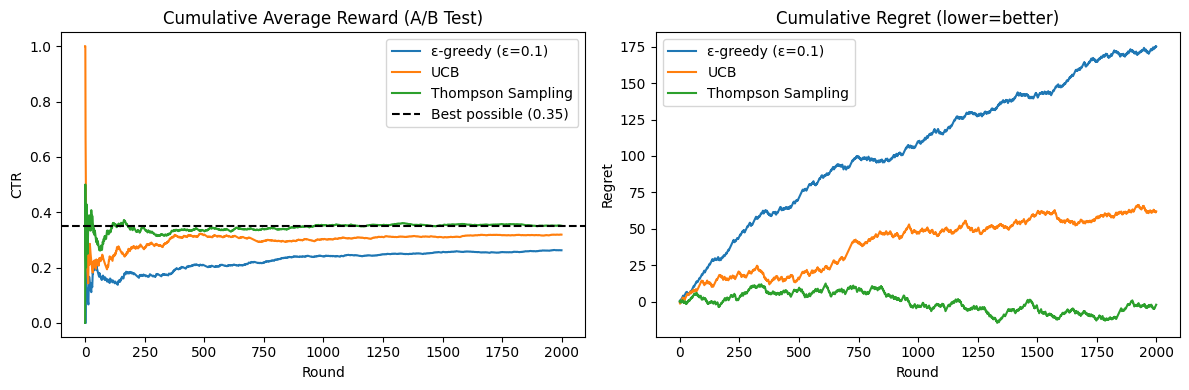


Total rewards — ε-greedy: 525, UCB: 638, Thompson: 702


In [2]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np, matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)
# ── Scenario: 5 website variants (like Netflix thumbnails)
# True click-through rates (unknown to agent)
# Save a value in a name so the next lines can read it.
TRUE_RATES = [0.15, 0.22, 0.35, 0.18, 0.28]   # Variant 3 is best (35%)
# Another assignment—same idea: store a value for the lines below.
N_ARMS   = len(TRUE_RATES)
# Another assignment—same idea: store a value for the lines below.
N_ROUNDS = 2000
# Recorder for the closing figure: at every round, UCB's score splits into
# an exploitation part (the running mean) and an exploration part (the confidence bonus).
ucb_trace = {"round": [], "mean": [], "bonus": [], "counts": []}

# Function `pull` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: arm.
def pull(arm): return 1 if np.random.rand() < TRUE_RATES[arm] else 0

# Function `epsilon_greedy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: eps.
def epsilon_greedy(eps):
    # Save a value in a name so the next lines can read it.
    counts = np.zeros(N_ARMS); totals = np.zeros(N_ARMS); rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for t in range(N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        arm = np.random.randint(N_ARMS) if np.random.rand()<eps else np.argmax(totals/(counts+1e-9))
        # Add one new item to the end of a list (the list grows in place).
        r = pull(arm); counts[arm]+=1; totals[arm]+=r; rewards.append(r)
    # Send a value back to whoever called this function.
    return rewards

# Function `ucb` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: no named parameters in the signature.
def ucb():
    # Save a value in a name so the next lines can read it.
    counts = np.zeros(N_ARMS); totals = np.zeros(N_ARMS); rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for arm in range(N_ARMS): r=pull(arm); counts[arm]=1; totals[arm]+=r; rewards.append(r)
    # Start a loop: repeat the indented block once per item in the sequence.
    for t in range(N_ARMS, N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        ucb_vals = totals/counts + np.sqrt(2*np.log(t+1)/counts)
        # Store both halves separately (bookkeeping only — the algorithm is unchanged).
        ucb_trace["round"].append(t)
        ucb_trace["mean"].append((totals/counts).copy())
        ucb_trace["bonus"].append(np.sqrt(2*np.log(t+1)/counts))
        ucb_trace["counts"].append(counts.copy())
        # Another assignment—same idea: store a value for the lines below.
        arm = np.argmax(ucb_vals)
        # Add one new item to the end of a list (the list grows in place).
        r = pull(arm); counts[arm]+=1; totals[arm]+=r; rewards.append(r)
    # Send a value back to whoever called this function.
    return rewards

# Function `thompson` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: no named parameters in the signature.
def thompson():
    # Save a value in a name so the next lines can read it.
    alpha = np.ones(N_ARMS); beta_ = np.ones(N_ARMS); rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        samples = np.random.beta(alpha, beta_)
        # Another assignment—same idea: store a value for the lines below.
        arm = np.argmax(samples)
        # Another assignment—same idea: store a value for the lines below.
        r = pull(arm)
        # If the condition is True, run the indented block under this line.
        if r: alpha[arm]+=1
        # Else: run this block when none of the if/elif tests above matched.
        else: beta_[arm]+=1
        # Add one new item to the end of a list (the list grows in place).
        rewards.append(r)
    # Send a value back to whoever called this function.
    return rewards

# Save a value in a name so the next lines can read it.
strategies = {
    # Another assignment—same idea: store a value for the lines below.
    'ε-greedy (ε=0.1)': epsilon_greedy(0.1),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'UCB':               ucb(),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'Thompson Sampling': thompson(),
# Part of a dict/set literal layout (syntax grouping).
}

# Function `cumavg` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: lst.
def cumavg(lst): return np.cumsum(lst) / np.arange(1,len(lst)+1)

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(12,4))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1,2,1)
# Start a loop: repeat the indented block once per item in the sequence.
for name, r in strategies.items():
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.plot(cumavg(r), label=name)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.axhline(max(TRUE_RATES), color='k', linestyle='--', label=f"Best possible ({max(TRUE_RATES)})")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Cumulative Average Reward (A/B Test)"); plt.xlabel("Round"); plt.ylabel("CTR"); plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1,2,2)
# Start a loop: repeat the indented block once per item in the sequence.
for name, r in strategies.items():
    # Regret so far = reward the best arm would have paid, minus the reward actually collected.
    regret_simple = np.cumsum(max(TRUE_RATES) - np.array(r))
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.plot(regret_simple, label=name)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Cumulative Regret (lower=better)"); plt.xlabel("Round"); plt.ylabel("Regret"); plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout(); plt.show()
# Show text or numbers in the cell output area under the code.
print(f"\nTotal rewards — ε-greedy: {sum(strategies['ε-greedy (ε=0.1)'])}, UCB: {sum(strategies['UCB'])}, Thompson: {sum(strategies['Thompson Sampling'])}")


### 👁️ Read the figure

- **Left, average reward per round.** The dashed line at **0.35** is what always showing
  variant 2 would earn. Thompson Sampling reaches it; **UCB ends just below it (~0.32)**;
  ε-greedy flattens near 0.26.
- **Right, cumulative regret — down is good.** UCB's orange curve *bends*: it loses reward
  quickly early (that is the mandatory one-pull-per-arm sweep plus the wide bonuses) and then
  the curve flattens near 60. ε-greedy's blue line stays straight, which means a constant loss
  per round with no end in sight.
- **The totals printed under the figure:** 525 conversions for ε-greedy, **638 for UCB**, 702
  for Thompson Sampling, on identical traffic.
- **Do not over-read one run.** These are three single runs on one 5-arm problem with one seed.
  The shape of the regret curves is the robust finding; the exact gap between UCB and Thompson
  here is not.

**What it proves:** UCB's early cost is real and visible, and it buys a regret curve that bends
instead of a straight line. That is the trade the rest of this lesson explains.

In [3]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Lai, T. L. & Robbins, H. (1985). *Asymptotically Efficient Adaptive Allocation Rules*. Advances in Applied Mathematics, 6, 4-22.
2. Auer, P., Cesa-Bianchi, N. & Fischer, P. (2002). *Finite-time Analysis of the Multiarmed Bandit Problem* (UCB1). Machine Learning, 47, 235-256. <https://link.springer.com/article/10.1023/A:1013689704352>
3. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 2.7, Upper-Confidence-Bound Action Selection.
4. Lattimore, T. & Szepesvári, C. (2020). *Bandit Algorithms*. Cambridge University Press.
5. Guan, X., Zhang, L. L., Liu, Y., Shang, N., Sun, Y., Zhu, Y., Yang, F. & Yang, M. (2025). *rStar-Math: Small LLMs Can Master Math Reasoning with Self-Evolved Deep Thinking*. arXiv:2501.04519. <https://arxiv.org/abs/2501.04519> — Monte Carlo tree search guided by a learned process reward model: the search-inside-a-tree use of this lesson's idea, two decades after UCT.
6. Jafari, D. & Farnia, F. (2026). *DAK-UCB: Diversity-Aware Prompt Routing for LLMs and Generative Models*. arXiv:2603.23140. <https://arxiv.org/abs/2603.23140> — a kernelized upper-confidence-bound contextual bandit that chooses online which generative model answers each prompt; the same bonus-for-uncertainty rule, new arms.
"""))

## 📚 References

1. Lai, T. L. & Robbins, H. (1985). *Asymptotically Efficient Adaptive Allocation Rules*. Advances in Applied Mathematics, 6, 4-22.
2. Auer, P., Cesa-Bianchi, N. & Fischer, P. (2002). *Finite-time Analysis of the Multiarmed Bandit Problem* (UCB1). Machine Learning, 47, 235-256. <https://link.springer.com/article/10.1023/A:1013689704352>
3. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 2.7, Upper-Confidence-Bound Action Selection.
4. Lattimore, T. & Szepesvári, C. (2020). *Bandit Algorithms*. Cambridge University Press.
5. Guan, X., Zhang, L. L., Liu, Y., Shang, N., Sun, Y., Zhu, Y., Yang, F. & Yang, M. (2025). *rStar-Math: Small LLMs Can Master Math Reasoning with Self-Evolved Deep Thinking*. arXiv:2501.04519. <https://arxiv.org/abs/2501.04519> — Monte Carlo tree search guided by a learned process reward model: the search-inside-a-tree use of this lesson's idea, two decades after UCT.
6. Jafari, D. & Farnia, F. (2026). *DAK-UCB: Diversity-Aware Prompt Routing for LLMs and Generative Models*. arXiv:2603.23140. <https://arxiv.org/abs/2603.23140> — a kernelized upper-confidence-bound contextual bandit that chooses online which generative model answers each prompt; the same bonus-for-uncertainty rule, new arms.


## 💬 Discuss

The measured run: **ε-greedy 525, UCB 638, Thompson Sampling 702** on identical arms. Argue these out.

1. UCB beat ε-greedy by 113 without a single tuned parameter beyond the confidence constant. But it
   lost to Thompson by 64. UCB's defence is that it comes with a proven regret bound and Thompson's
   guarantee arrived much later. In a project review, is "it has a bound" worth 64 points of measured
   reward? Argue both sides, then say what you would actually deploy.
2. UCB's bonus is `sqrt(2·ln(t)/N(a))` — it grows with total time `t` and shrinks with that arm's own
   count `N(a)`. Explain, without formulas, why the `ln(t)` term has to be there at all. What would go
   wrong if the bonus depended only on `N(a)`?
3. UCB assumes an arm's payoff does not change. In a Go tree that is true — a position is a position.
   In a pricing system it is not. Describe what UCB does when an arm's true value drops *after* it has
   been sampled a thousand times, and how long you would expect it to take to notice.


## 📝 Summary

You compared **exploration strategies**: ε-greedy (simple, effective), UCB (optimism under uncertainty), and Thompson Sampling (Bayesian). The exploration-exploitation tradeoff is central to RL. Real applications: A/B testing at Netflix, ad bidding at Google, recommendation engines at Spotify.

### Step Guide

**What this cell does:** Draws the closing figure of this lesson — UCB's score pulled apart into its two halves: the value estimate it exploits, and the confidence bonus it explores with.

**How to read it (weak Python OK):** Nothing new is trained. The UCB run above recorded both terms at every round into `ucb_trace`; this cell plots them.

**What to expect in the output:** One figure with two panels — the shrinking bonus over 2,000 rounds on the left, a stacked bar per arm at the final round on the right — plus a printed table.

**If you feel lost:** Re-run the worked-example cell above so `ucb_trace` is filled, then run this cell again.

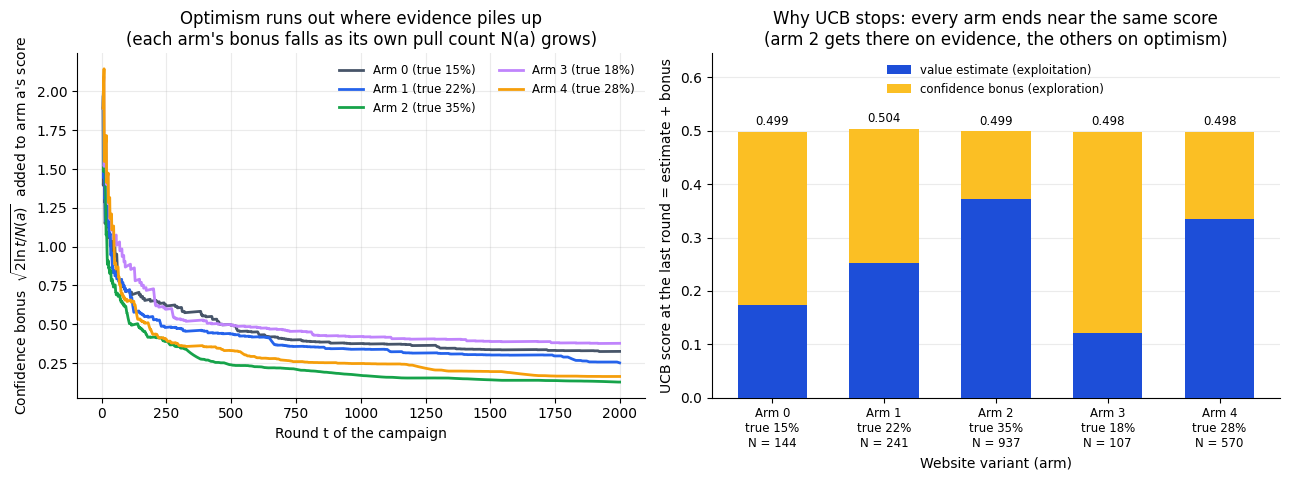

Entering the final round (N = pulls made so far), UCB's score for each arm:
  arm     N      estimate   + bonus   =  score
   0      144     0.174     0.325     0.499
   1      241     0.253     0.251     0.504
   2      937     0.371     0.127     0.499
   3      107     0.121     0.377     0.498
   4      570     0.335     0.163     0.498

Spread between the highest and lowest score: 0.006


In [4]:
# Closing figure: UCB's whole idea in one picture.
# score(a) = running mean of arm a   +   sqrt(2 * ln t / N(a))
#            ^ exploitation              ^ exploration bonus, shrinks as the arm is pulled
import numpy as np
import matplotlib.pyplot as plt

rounds = np.array(ucb_trace["round"])            # round index t (a real timeline: a line is fair here)
bonus = np.array(ucb_trace["bonus"])             # shape (rounds, arms)
mean_est = np.array(ucb_trace["mean"])
counts = np.array(ucb_trace["counts"])

arm_colors = ["#475569", "#2563eb", "#16a34a", "#c084fc", "#f59e0b"]
best_arm = int(np.argmax(TRUE_RATES))

fig, (ax_bonus, ax_split) = plt.subplots(1, 2, figsize=(13, 4.9))

# ---------- Left: how the confidence bonus of each arm evolves ----------
for arm, color in enumerate(arm_colors):
    ax_bonus.plot(rounds, bonus[:, arm], color=color, lw=2.0,
                  label=f"Arm {arm} (true {TRUE_RATES[arm]:.0%})")
ax_bonus.set_xlabel("Round t of the campaign")
ax_bonus.set_ylabel("Confidence bonus  $\\sqrt{2\\ln t / N(a)}$  added to arm a's score")
ax_bonus.set_title("Optimism runs out where evidence piles up\n"
                   "(each arm's bonus falls as its own pull count N(a) grows)")
ax_bonus.legend(fontsize=8.5, frameon=False, ncol=2)
ax_bonus.spines[["top", "right"]].set_visible(False)
ax_bonus.grid(alpha=0.25)

# ---------- Right: the final score of every arm, split into its two parts ----------
final_mean = mean_est[-1]
final_bonus = bonus[-1]
final_counts = counts[-1]
x = np.arange(N_ARMS)                            # five arms: categories, so bars and never a line

bars_lo = ax_split.bar(x, final_mean, 0.62, color="#1d4ed8",
                       label="value estimate (exploitation)", zorder=3)
bars_hi = ax_split.bar(x, final_bonus, 0.62, bottom=final_mean, color="#fbbf24",
                       label="confidence bonus (exploration)", zorder=3)

# Write the total UCB score above each stacked bar.
for xi, (m, b) in enumerate(zip(final_mean, final_bonus)):
    ax_split.text(xi, m + b + 0.012, f"{m + b:.3f}", ha="center", fontsize=8.5)

ax_split.set_xticks(x)
ax_split.set_xticklabels([f"Arm {i}\ntrue {TRUE_RATES[i]:.0%}\nN = {int(final_counts[i])}"
                          for i in range(N_ARMS)], fontsize=8.5)
ax_split.set_xlabel("Website variant (arm)")
ax_split.set_ylabel("UCB score at the last round = estimate + bonus")
ax_split.set_title(f"Why UCB stops: every arm ends near the same score\n"
                   f"(arm {best_arm} gets there on evidence, the others on optimism)")
ax_split.set_ylim(0, max(final_mean + final_bonus) * 1.28)
ax_split.legend(fontsize=8.5, frameon=False, loc="upper center")
ax_split.spines[["top", "right"]].set_visible(False)
ax_split.grid(axis="y", alpha=0.25, zorder=0)

plt.tight_layout()
plt.show()

print("Entering the final round (N = pulls made so far), UCB's score for each arm:")
print("  arm     N      estimate   + bonus   =  score")
for i in range(N_ARMS):
    print(f"   {i}    {int(final_counts[i]):5d}     {final_mean[i]:.3f}     {final_bonus[i]:.3f}"
          f"     {final_mean[i] + final_bonus[i]:.3f}")
print(f"\nSpread between the highest and lowest score: "
      f"{(final_mean + final_bonus).max() - (final_mean + final_bonus).min():.3f}")


### 👁️ Read the figure

**Left — the bonus is not a constant, it is a countdown.** Five curves, one per arm, over the
2,000 rounds. Every curve starts near 2.1 (one pull each, maximum ignorance) and falls, but at
very different speeds. **Green (arm 2) falls fastest and ends lowest (0.127)** — it was pulled
937 times, so `N(a)` in the denominator grew fast. **Purple (arm 3) ends highest (0.377)** on
just 107 pulls. Look closely and the curves are staircases with tiny *upward* steps: while an
arm is not being pulled, `ln t` keeps growing and its bonus creeps back up. That is UCB
quietly re-opening the case for an arm it has been ignoring.

**Right — why the run settles.** Each bar is one arm's final score split into the two terms of
the formula. Read the totals printed above the bars: **0.499, 0.504, 0.499, 0.498, 0.498** —
a spread of **0.006** across five arms whose true rates run from 15% to 35%.
- **Arm 2 reaches ~0.50 on evidence**: a large blue block (estimate 0.371) and a small yellow
  one (bonus 0.127).
- **Arm 3 reaches the same ~0.50 on optimism**: a small blue block (0.121) and the largest
  yellow one (0.377).

**What it proves:** UCB does not "pick the best arm and stop". It drives every arm to the same
upper confidence bound, and the *only* way an arm stays there while being pulled thousands of
times is to actually be good. The bad arms hold their position purely on the uncertainty that
has not yet been paid off — which is also why the ⚠️ section below is right that a
ten-thousand-arm catalogue would be all bonus and no evidence.

## ⚠️ Where this breaks

**The assumption that has to hold:** the reward of each arm is drawn from a fixed distribution with
bounded range, and every arm can be tried at least once.

- **UCB must try everything once, and pays for it.** The bonus is infinite for an unpulled arm, so
  the algorithm sweeps the whole action set before it starts exploiting. With three arms that is
  free. With ten thousand candidate articles it is the entire budget — which is why production
  systems use *contextual* variants that share information between arms rather than plain UCB.
- **Non-stationarity defeats it in a specific, ugly way.** The bonus shrinks with `N(a)`. An arm that
  has been pulled a thousand times has almost no bonus left, so if its true value rises later, UCB is
  structurally slow to find out — slower than ε-greedy, which keeps sampling blindly and would
  stumble on it. Sliding-window and discounted UCB variants exist for this reason.
- **The confidence constant is a tuning knob in disguise.** The theory fixes the form, not the
  multiplier. Change it and you change the explore/exploit balance as surely as changing ε.
- **Bounded rewards, or the bound is wrong.** UCB1's guarantee assumes rewards in a known range.
  Revenue per customer with a long tail violates it, and the bonus then under-explores exactly the
  arms whose rare large payoffs matter.
- **Cheaper alternative:** Thompson sampling needs no bonus term, handles Bayesian priors naturally,
  and beat UCB on this run and in Chapelle and Li's real-data study. Prefer UCB when you need a
  worst-case regret guarantee you can write in a document, or when you are inside a tree search and
  need a deterministic, cheap rule at every node.


## Closing Takeaway

**Teaching takeaway:** UCB explores based on uncertainty, giving extra attention to actions that may be promising but have not been tested enough.

**If students remember one idea:** Adaptive exploration uses what the agent has learned so far to decide where uncertainty is still worth paying for.

**Quick check before moving on:**
- Can you explain why UCB adds an uncertainty bonus to estimated value?
- Can you describe what happens to that bonus as an action is sampled more often?

**Bridge to the next step:** The next lesson compares multiple exploration methods so students can judge trade-offs more directly.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=10 | term=True | trunc=False


objc[55494]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11019c138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1106dc9c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[55494]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11019c188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1106dca18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[55494]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11019bc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1106dca68). T

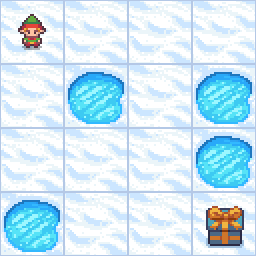

In [5]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
